# 01 · Data Preparation & Structural Readiness

**Project:** Predicting essential-price shocks across income quintiles in Pakistan (DS4SG, CS/SDP 312/314)
**Team:** Syeda Hoorain Imran (CS) · Muhammad Munib Sattar (SDP) · Sarah Khalid (SDP)
**Research question:** Can weekly price shocks in essential items be predicted, and how do their size and predictability differ across consumption quintiles? (SDG 1, 2, 10)

This notebook takes the master dataset produced by the collection pipeline and makes it **modeling-ready**. Every
decision is shown with the numbers behind it. It covers Milestone 2, Sections 1.2 and 2:

| Rubric item | Section of this notebook |
|---|---|
| 1.2 Master dataset overview | §1 |
| 2.1 Scraping / collection audit | §2.1 (full write-up in `manuscript/02_data_collection_audit.md`) |
| 2.2 Data alignment & structural organisation (melt / pivot / joins) | §2.2 |
| 2.3 Missing data: counts, %, strategy, selection bias | §2.3 |
| 2.4 Log transforms, scaling, categorical encoding | §2.4 |

**How to reproduce.** Raw files are not stored in git. Rebuild them with the pipeline scripts, run in this order from the project root:

```
python src/scraping/spi_catalogue.py      # list every weekly SPI file (PBS site + Wayback Machine)
python src/scraping/spi_download.py       # download one report per week (slow: polite to the archive)
python src/cleaning/parse_spi.py          # extract the quintile and item tables
python src/scraping/fx_rates.py           # PKR/USD daily
python src/features/build_event_calendar.py
python src/scraping/sbp_mps.py            # SBP policy-rate decisions
python src/cleaning/build_master.py       # master dataset (input to this notebook)
```

In [1]:
# --- Setup -------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Find the project root (the folder containing CLAUDE.md), so the notebook runs from any folder.
ROOT = Path.cwd()
while not (ROOT / "CLAUDE.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from cleaning.build_master import nearest_thursday   # the same week-alignment rule as the pipeline
from utils.plot_style import apply_style, SERIES, INK_SECONDARY

apply_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA = ROOT / "data"
FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
GROUPS = ["Q1", "Q2", "Q3", "Q4", "Q5", "Combined"]

# Provisional time split used for scaling in §2.4. Statistics are learned on the training period
# only, so nothing about the future leaks into the model. Weeks after TRAIN_END are held out.
TRAIN_END = pd.Timestamp("2024-12-31")

In [2]:
# --- Load the pipeline outputs -------------------------------------------------
master = pd.read_csv(DATA / "processed" / "master_weekly_quintile.csv",
                     parse_dates=["week_end", "week_end_reported"])
items_raw = pd.read_csv(DATA / "interim" / "spi_items_weekly.csv", parse_dates=["week_end"])
item_info = pd.read_csv(DATA / "external" / "spi_items.csv")          # 51 items: category + weights
manifest = pd.read_csv(DATA / "raw" / "spi_weekly" / "manifest.csv", dtype=str)
parse_log = pd.read_csv(DATA / "interim" / "spi_parse_log.csv")
mpc = pd.read_csv(DATA / "external" / "sbp_mpc_decisions.csv", parse_dates=["decision_date"])

print(f"master dataset : {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"item-level rows: {items_raw.shape[0]:,} (week x item, as parsed from the reports)")

master dataset : 2,220 rows x 36 columns
item-level rows: 18,309 (week x item, as parsed from the reports)


## 1. Master dataset inventory (rubric §1.2)

The **observational unit** is one *SPI week* (the week ending Thursday) for one *consumption group*. The groups are the
five quintiles Q1 (poorest, monthly spending up to Rs 17,732) to Q5 (richest, above Rs 44,175), plus the national
*Combined* index. Using a long ("tidy") layout means one model can learn across all groups at once, with a group
indicator, while each group keeps its own time series.

In [3]:
n_weeks = master["week_end"].nunique()
inventory = pd.DataFrame({
    "Property": [
        "Observational unit", "Groups", "Period", "Weeks", "Rows (observations)",
        "Columns (variables, before preparation)", "Secondary dataset",
        "Source: target and price data", "Source: policy rate", "Source: exchange rate", "Source: calendar events",
    ],
    "Value": [
        "1 row = 1 SPI week (ending Thursday) x 1 consumption group",
        ", ".join(GROUPS),
        f"{master['week_end'].min():%d %b %Y} to {master['week_end'].max():%d %b %Y}",
        f"{n_weeks}",
        f"{len(master):,}",
        f"{master.shape[1]}",
        f"item panel: 1 row = 1 week x 1 of 51 items ({n_weeks * 51:,} rows after completion, see §2.2)",
        "PBS weekly Sensitive Price Indicator reports (old PBS site via Wayback Machine + current PBS site)",
        "SBP Monetary Policy Statements and press releases (66 decisions, 2018-2026)",
        "Yahoo Finance PKR=X, daily, aggregated to SPI weeks",
        "Umm al-Qura calendar (hijridate) with Pakistan-specific date overrides",
    ],
})
display(inventory.style.hide(axis="index"))

Property,Value
Observational unit,1 row = 1 SPI week (ending Thursday) x 1 consumption group
Groups,"Q1, Q2, Q3, Q4, Q5, Combined"
Period,05 Sep 2019 to 01 Oct 2026
Weeks,370
Rows (observations),"2,220"
"Columns (variables, before preparation)",36
Secondary dataset,"item panel: 1 row = 1 week x 1 of 51 items (18,870 rows after completion, see §2.2)"
Source: target and price data,PBS weekly Sensitive Price Indicator reports (old PBS site via Wayback Machine + current PBS site)
Source: policy rate,"SBP Monetary Policy Statements and press releases (66 decisions, 2018-2026)"
Source: exchange rate,"Yahoo Finance PKR=X, daily, aggregated to SPI weeks"


In [4]:
# A first look at the key columns for the most recent week.
cols = ["week_end", "group", "spi", "spi_wow_pct", "spi_yoy_pct", "fx_pkr_usd_wavg", "policy_rate",
        "fuel_revision_week", "ramadan_days_in_week", "target_spi_wow_pct_next"]
display(master.loc[master["week_end"] == master["week_end"].max(), cols])

,week_end,group,spi,spi_wow_pct,spi_yoy_pct,fx_pkr_usd_wavg,policy_rate,fuel_revision_week,ramadan_days_in_week,target_spi_wow_pct_next
369,2026-10-01,Combined,370.46,0.208283,11.527230,270.232245,11.5,True,0,NaN
739,2026-10-01,Q1,354.73,0.189233,9.003472,270.232245,11.5,True,0,NaN
1109,2026-10-01,Q2,358.13,0.204253,10.756147,270.232245,11.5,True,0,NaN
1479,2026-10-01,Q3,378.66,0.206415,9.401364,270.232245,11.5,True,0,NaN
1849,2026-10-01,Q4,366.01,0.219052,9.810687,270.232245,11.5,True,0,NaN
2219,2026-10-01,Q5,370.22,0.208418,11.994434,270.232245,11.5,True,0,NaN


## 2.1 Collection audit (rubric §2.1)

PBS publishes **no consolidated historical file**. Each week is a separate report, and the old PBS website, which
held 2019–2023, no longer exists. The pipeline rebuilds the history from two sources:

1. the **current PBS website**: its price page embeds a JavaScript list of every weekly file (Jul 2023 onward;
   Excel only from Oct 2025);
2. the **Wayback Machine**, which preserved the old PBS website's SPI folders, listed through its CDX index API.

Every download is checked for the base year (2015-16 = 100) and for being a real PDF/Excel file, and is logged with
a SHA-256 checksum in `data/raw/spi_weekly/manifest.csv`. The tables below summarise that audit trail.

In [5]:
ok = manifest[manifest["status"] == "ok"].drop_duplicates(["week_date", "kind"], keep="last").copy()
ok["format"] = ok["local_path"].str.rsplit(".", n=1).str[-1].str.upper()
audit = (ok.groupby(["source", "format"]).size().rename("reports").reset_index()
           .replace({"source": {"wayback": "Wayback Machine (old PBS site)",
                                "pbs_live": "Current PBS website"}}))
display(audit.style.hide(axis="index"))

failed = manifest[manifest["status"] == "failed"]
complete = parse_log["quintile_ok"] & parse_log["n_items"].eq(51)
filled = master.loc[master["group"] == "Combined", "filled_from_next_report"].sum()
print(f"Reports downloaded and validated : {len(ok)}")
print(f"Failed download attempts         : {len(failed)} (all '{failed['note'].unique()[0]}': dead links in the "
      f"PBS catalogue; see audit document)")
print(f"Reports parsed completely        : {complete.sum()} of {len(parse_log)} "
      f"(base 2015-16 confirmed in {parse_log['base'].eq('2015-16').sum()})")
print(f"Thursdays from first to last week: {n_weeks}; without their own report: {filled} "
      f"(filled from the next report, see §2.3)")

source,format,reports
Current PBS website,PDF,86
Current PBS website,XLSX,51
Wayback Machine (old PBS site),PDF,222


Reports downloaded and validated : 359
Failed download attempts         : 15 (all 'HTTP 404': dead links in the PBS catalogue; see audit document)
Reports parsed completely        : 359 of 359 (base 2015-16 confirmed in 359)
Thursdays from first to last week: 370; without their own report: 11 (filled from the next report, see §2.3)


## 2.2 Structural organisation: tidy layout, reshaping and merging (rubric §2.2)

**Tidy data** (Unit 03): each variable is a column, each observation a row, each type of observational unit a table.
The reports arrive in a presentation layout: a quintile table with groups as rows and weeks as columns, and an item
table sorted by "increased / decreased / unchanged". The parser stores both in long format. Below we

1. show that the quintile data can move losslessly between **long** (modeling) and **wide** (comparison) layouts with
   `pivot` and `melt`;
2. build the **item panel** (week × item) on a complete grid, so missing weeks become explicit rows;
3. aggregate PBS's item-level *impacts* into **category contributions** (food, energy, …), `pivot` them to one column
   per category, and **join** them onto the master dataset.

In [6]:
# (1) Long <-> wide round trip.
long = master[["week_end", "group", "spi"]]

# pivot: one row per week, one column per group. Useful for comparing groups side by side.
wide = long.pivot(index="week_end", columns="group", values="spi")[GROUPS]
display(wide.tail(3).round(2))

# melt: back to one row per week x group. The round trip must reproduce the data exactly.
back = wide.reset_index().melt(id_vars="week_end", var_name="group", value_name="spi_back")
check = long.merge(back, on=["week_end", "group"])
assert len(check) == len(long) and np.allclose(check["spi"], check["spi_back"])
print(f"pivot -> melt round trip reproduces all {len(check):,} rows exactly")

group,Q1,Q2,Q3,Q4,Q5,Combined
week_end,,,,,,
2026-09-17,351.07,352.87,374.83,362.97,366.32,366.05
2026-09-24,354.06,357.40,377.88,365.21,369.45,369.69
2026-10-01,354.73,358.13,378.66,366.01,370.22,370.46


pivot -> melt round trip reproduces all 2,220 rows exactly


**(2) Item panel.** Each report lists all 51 items. We align every report to its Thursday (the same rule as the
master dataset) and build a complete week × item grid. For the 11 weeks without their own report, each item's price is
taken from the **next** report's "previous week" column. That's an official PBS figure, the same rule as decision D2 for
the index. The fixed basket weights and our item categories come from `data/external/spi_items.csv`.

In [7]:
# The basket weights are fixed by the 2015-16 base, so they should never change from week to week.
n_weights = items_raw.groupby("item_id")[["weight_q1", "weight_combined"]].nunique().max()
print("distinct weights per item (expect 1):", n_weights.to_dict())

items = items_raw.copy()
items["week_end"] = items["week_end"].map(nearest_thursday)

# Complete grid: every week x every item, so a missing week shows up as a row of NaNs.
weeks = pd.Index(sorted(master["week_end"].unique()), name="week_end")
grid = pd.MultiIndex.from_product([weeks, item_info["item_id"]], names=["week_end", "item_id"])
items = items.set_index(["week_end", "item_id"]).reindex(grid).reset_index()
items = items.sort_values(["item_id", "week_end"]).reset_index(drop=True)

# Fill a missing week's price from the next report's "previous week" price (official PBS value).
next_prev = items.groupby("item_id")["price_prev_week"].shift(-1)
fill = items["price"].isna() & next_prev.notna()
items.loc[fill, "price"] = next_prev[fill]
items["price_filled_from_next_report"] = fill

# Recompute week-on-week % change from the completed price series.
items["price_wow_pct"] = items.groupby("item_id")["price"].pct_change(fill_method=None) * 100

# Attach the official item name, unit, weights and our category (replacing the per-report copies).
items = (items.drop(columns=["item_name_raw", "unit", "weight_q1", "weight_combined", "match_score"])
              .merge(item_info, on="item_id", how="left"))

print(f"item panel: {len(items):,} rows = {items['week_end'].nunique()} weeks x {items['item_id'].nunique()} items")
print(f"item prices filled from the next report: {fill.sum()} ({fill.sum() // 51} weeks x 51 items)")
print(f"item prices still missing: {items['price'].isna().sum()}")

distinct weights per item (expect 1): {'weight_q1': 1, 'weight_combined': 1}


item panel: 18,870 rows = 370 weeks x 51 items
item prices filled from the next report: 561 (11 weeks x 51 items)
item prices still missing: 0


**(3) Category contributions.** For every item, each report gives its *impact*: how many percentage points it added
to that week's index change, for the lowest quintile and for the combined index. Summing the impacts by category tells
us **what drove each week's inflation, and for whom**. That is the core input for comparing quintiles (H2). PBS
publishes impacts only for the lowest quintile and Combined, not for Q2–Q5.

Two data-quality steps come first:
* In the very first new-base report (5 Sep 2019) PBS printed the lowest-quintile impact column twice, so the Combined
  impacts for that week are wrong. They are set to missing.
* As a check, the item impacts should add up to the reported weekly % change of the index.

In [8]:
# PBS formatting error: on 5 Sep 2019 the "combined" impact column repeats the lowest-quintile column.
first_week = items["week_end"].eq(pd.Timestamp("2019-09-05"))
assert (items.loc[first_week, "impact_q1"] == items.loc[first_week, "impact_combined"]).all()
items.loc[first_week, "impact_combined"] = np.nan

# Sum impacts by week and category. min_count=1 keeps NaN (not 0) for weeks without impacts.
contrib = (items.groupby(["week_end", "category"])[["impact_q1", "impact_combined"]]
                .sum(min_count=1)
                .unstack("category"))
contrib.columns = [f"contrib_{cat}_{'q1' if col == 'impact_q1' else 'comb'}" for col, cat in contrib.columns]

# Check: the categories together must reproduce the reported weekly change of the index.
reported = master.pivot(index="week_end", columns="group", values="pct_wow_reported")
chk = pd.DataFrame({
    "Q1": (contrib.filter(like="_q1").sum(axis=1, min_count=1) - reported["Q1"]).abs(),
    "Combined": (contrib.filter(like="_comb").sum(axis=1, min_count=1) - reported["Combined"]).abs(),
})
display(chk.describe().loc[["count", "50%", "max"]].round(4)
           .rename(index={"count": "weeks checked", "50%": "median abs. difference (pp)",
                          "max": "max abs. difference (pp)"}))

,Q1,Combined
weeks checked,359.0000,358.0000
median abs. difference (pp),0.0024,0.0022
max abs. difference (pp),0.0101,0.0114


In [9]:
# Join the weekly category contributions onto every group's row for that week.
df = master.merge(contrib.reset_index(), on="week_end", how="left", validate="many_to_one")
print(f"after join: {df.shape[0]:,} rows x {df.shape[1]} columns (rows unchanged: {len(df) == len(master)})")
display(df.loc[df["group"] == "Combined", ["week_end"] + list(contrib.columns)].tail(3).round(3))

after join: 2,220 rows x 44 columns (rows unchanged: True)


D:\devtemp\ipykernel_26000\2315527286.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(df.loc[df["group"] == "Combined", ["week_end"] + list(contrib.columns)].tail(3).round(3))


,week_end,contrib_clothing_footwear_q1,contrib_energy_q1,contrib_food_q1,contrib_household_q1,contrib_clothing_footwear_comb,contrib_energy_comb,contrib_food_comb,contrib_household_comb
367,2026-09-17,0.000,0.164,-0.303,0.000,0.000,0.660,-0.169,0.000
368,2026-09-24,0.000,1.237,-0.391,0.005,0.000,1.195,-0.202,0.003
369,2026-10-01,0.006,-0.000,0.180,0.004,0.005,-0.035,0.235,0.002


## 2.3 Missing data (rubric §2.3)

First, the full picture: missing counts and percentages for every variable that has any missing values.

In [10]:
def missing_table(frame):
    # Count and percentage of missing values per column (only columns with at least one).
    n = frame.isna().sum()
    out = pd.DataFrame({"missing": n, "percent": (100 * n / len(frame)).round(2)})
    return out[out["missing"] > 0].sort_values(["percent", "missing"], ascending=False)

before = missing_table(df)
print(f"{df.shape[1] - len(before)} of {df.shape[1]} columns have no missing values. The rest:")
display(before)
before.to_csv(TABLE_DIR / "missing_values_before.csv")

19 of 44 columns have no missing values. The rest:


,missing,percent
contrib_clothing_footwear_comb,72,3.24
contrib_energy_comb,72,3.24
contrib_food_comb,72,3.24
contrib_household_comb,72,3.24
spi_prev_week,66,2.97
spi_year_ago,66,2.97
pct_wow_reported,66,2.97
pct_yoy_reported,66,2.97
source_file,66,2.97
week_end_reported,66,2.97


Every missing value falls into one of three groups, and each gets its own strategy:

| Type | Columns | Why missing | Strategy |
|---|---|---|---|
| **A. Structural** | lags, w/w changes, next-week target | the first week has no previous week, the last week has no next week | keep as NaN; **listwise deletion** of those few rows when fitting models |
| **B. Weeks without their own report** (11 weeks × 6 groups = 2.97%) | year-ago SPI and y/y %, reported % columns, fuel % changes | nothing was published that week (several are Eid weeks) | **recover from other official figures** where possible (below); no statistical imputation |
| **C. Contributions** | `contrib_*` | impacts exist only in a week's own report | keep as NaN; analyses using contributions drop these weeks |

We avoid mean or median imputation for the target and the main predictors. A weekly price index is a time series:
replacing a missing week with the sample mean would invent a price jump and back. Where an **official value exists
elsewhere**, we use it instead.

In [11]:
df = df.sort_values(["group", "week_end"]).reset_index(drop=True)

# --- B1: year-ago SPI. Use the reported "corresponding week last year" where available; otherwise
# take the group's own value 52 weeks earlier. First check that the two agree where both exist.
lag52 = df.groupby("group")["spi"].shift(52)
both = df["spi_year_ago"].notna() & lag52.notna()
diff = (df.loc[both, "spi_year_ago"] - lag52[both]).abs()
print(f"reported year-ago vs own value 52 weeks earlier: {both.sum()} pairs, "
      f"median abs. diff {diff.median():.3f} points, within 0.5 points: {(diff <= 0.5).mean():.1%}")

fill_yago = df["spi_year_ago"].isna() & lag52.notna()
df.loc[fill_yago, "spi_year_ago"] = lag52[fill_yago]
df["spi_year_ago_from_lag52"] = fill_yago
df["spi_yoy_pct"] = (df["spi"] / df["spi_year_ago"] - 1) * 100
print(f"year-ago values filled from the 52-week lag: {fill_yago.sum()} rows")

reported year-ago vs own value 52 weeks earlier: 1842 pairs, median abs. diff 0.000 points, within 0.5 points: 99.7%
year-ago values filled from the 52-week lag: 66 rows


In [12]:
# --- B2: fuel prices. The completed item panel (§2.2) has petrol and diesel prices for every week,
# so recompute their w/w change and the fuel-revision flag (|change| > 1%, decision D5) for all weeks.
fuel = (items[items["item_id"].isin(["petrol", "diesel"])]
        .pivot(index="week_end", columns="item_id", values="price_wow_pct")
        .rename(columns=lambda c: f"{c}_pct_wow"))
fuel["fuel_revision_week"] = (fuel.abs() > 1.0).any(axis=1).astype(float)   # 1.0 / 0.0, NaN below
fuel.loc[fuel[["petrol_pct_wow", "diesel_pct_wow"]].isna().all(axis=1), "fuel_revision_week"] = np.nan

df = (df.drop(columns=["petrol_pct_wow", "diesel_pct_wow", "fuel_revision_week"])
        .merge(fuel.reset_index(), on="week_end", how="left", validate="many_to_one"))
print(f"fuel-revision weeks: {int(fuel['fuel_revision_week'].sum())} of {fuel['fuel_revision_week'].notna().sum()}")

fuel-revision weeks: 127 of 369


**Selection bias.** Missing weeks are *not* random. PBS skips its release in some holiday weeks, especially Eid. If
Eid weeks were simply dropped, the data would under-represent exactly the weeks H1 is about (calendar events), and an
"Eid effect" estimated from the rest would be biased. The check below measures how strongly missingness is tied to Eid.

In [13]:
wk = df[df["group"] == "Combined"].copy()
# An "Eid week" here: Eid falls in this SPI week or the one before (releases are often delayed a week).
eid_now = (wk["eid_fitr_days_in_week"] > 0) | (wk["eid_adha_days_in_week"] > 0)
wk["eid_window"] = eid_now | eid_now.shift(1, fill_value=False)
tab = pd.crosstab(wk["filled_from_next_report"].map({True: "no own report", False: "own report"}),
                  wk["eid_window"].map({True: "Eid window", False: "other weeks"}))
display(tab)
share_missing = wk.loc[wk["filled_from_next_report"], "eid_window"].mean()
share_all = wk["eid_window"].mean()
print(f"Eid-window weeks: {share_all:.1%} of all weeks, but {share_missing:.1%} of the weeks without a report")

eid_window,Eid window,other weeks
filled_from_next_report,,
no own report,7,4
own report,26,333


Eid-window weeks: 8.9% of all weeks, but 63.6% of the weeks without a report


The weeks without a report are **heavily concentrated around Eid**, compared with the share of Eid-window weeks
overall (see the printed shares above). Missingness is therefore related to the very calendar events we want to study.

Because the **index itself** was recovered from PBS's own previous-week figures (decision D2), the target and the
SPI-based predictors keep every week, Eid weeks included. Bias can only enter analyses that use **category
contributions** (type C), which do drop these weeks. Those analyses must say so and, as a robustness check, be repeated
without the Eid windows.

In [14]:
after = missing_table(df)
display(after)
after.to_csv(TABLE_DIR / "missing_values_after.csv")
print("Remaining gaps are structural (type A) or contributions (type C), as planned above.")

,missing,percent
contrib_clothing_footwear_comb,72,3.24
contrib_energy_comb,72,3.24
contrib_food_comb,72,3.24
contrib_household_comb,72,3.24
spi_prev_week,66,2.97
pct_wow_reported,66,2.97
pct_yoy_reported,66,2.97
source_file,66,2.97
week_end_reported,66,2.97
contrib_clothing_footwear_q1,66,2.97


Remaining gaps are structural (type A) or contributions (type C), as planned above.


## 2.4 Transformations and encoding (rubric §2.4)

### Skewness and log transforms

A log transform suits **positive, right-skewed** variables, and variables that grow **multiplicatively**. A price index
that rises 10% a year roughly doubles in seven years, and on the log scale that becomes a straight line. Percentage
changes can be negative, so they cannot be logged; we look at their tails (kurtosis) instead and treat outliers in
the EDA notebook.

In [15]:
df["log_fx"] = np.log(df["fx_pkr_usd_wavg"])
items["log_price"] = np.log(items["price"])

cont = ["spi", "fx_pkr_usd_wavg", "policy_rate", "spi_wow_pct", "spi_yoy_pct", "fx_wow_pct"]
skew = pd.DataFrame({"skewness": df[cont].skew(), "excess kurtosis": df[cont].kurt()})
skew.loc["item price (all items, PKR)"] = [items["price"].skew(), items["price"].kurt()]
skew.loc["log item price"] = [items["log_price"].skew(), items["log_price"].kurt()]
skew.loc["log SPI"] = [df["log_spi"].skew(), df["log_spi"].kurt()]
display(skew.round(2))

,skewness,excess kurtosis
spi,-0.03,-1.64
fx_pkr_usd_wavg,-0.28,-1.76
policy_rate,0.52,-0.95
spi_wow_pct,1.29,31.09
spi_yoy_pct,0.64,-0.34
fx_wow_pct,3.58,33.90
"item price (all items, PKR)",2.66,7.92
log item price,-0.97,1.85
log SPI,-0.23,-1.59


**Reading the table**

* **Item prices** are the textbook case for a log: strong right skew (2.66) and heavy tails, because cheap items
  (a matchbox) sit next to expensive ones (an LPG cylinder). The log cuts the skew to −0.97 and the kurtosis from 7.9
  to 1.9. It slightly over-corrects, leaving a short left tail of very cheap per-unit items. This matters because
  models and averages on raw prices would be dominated by the few expensive items.
* **SPI and FX levels** are *not* skewed as distributions (skewness ≈ 0, negative kurtosis), because they are
  trending series. We still log them for a different reason: they grow **multiplicatively**, so differences of logs
  are (approximately) % changes and a constant inflation rate becomes a straight line.
* **Weekly % changes** (`spi_wow_pct`, `fx_wow_pct`) are only moderately skewed but have **very heavy tails**
  (excess kurtosis above 30). Most weeks are calm, and a few weeks carry huge jumps (fuel revisions, devaluations).
  They cannot be logged (negative values). We keep them as they are and examine the extreme weeks with both outlier
  rules in the EDA notebook.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


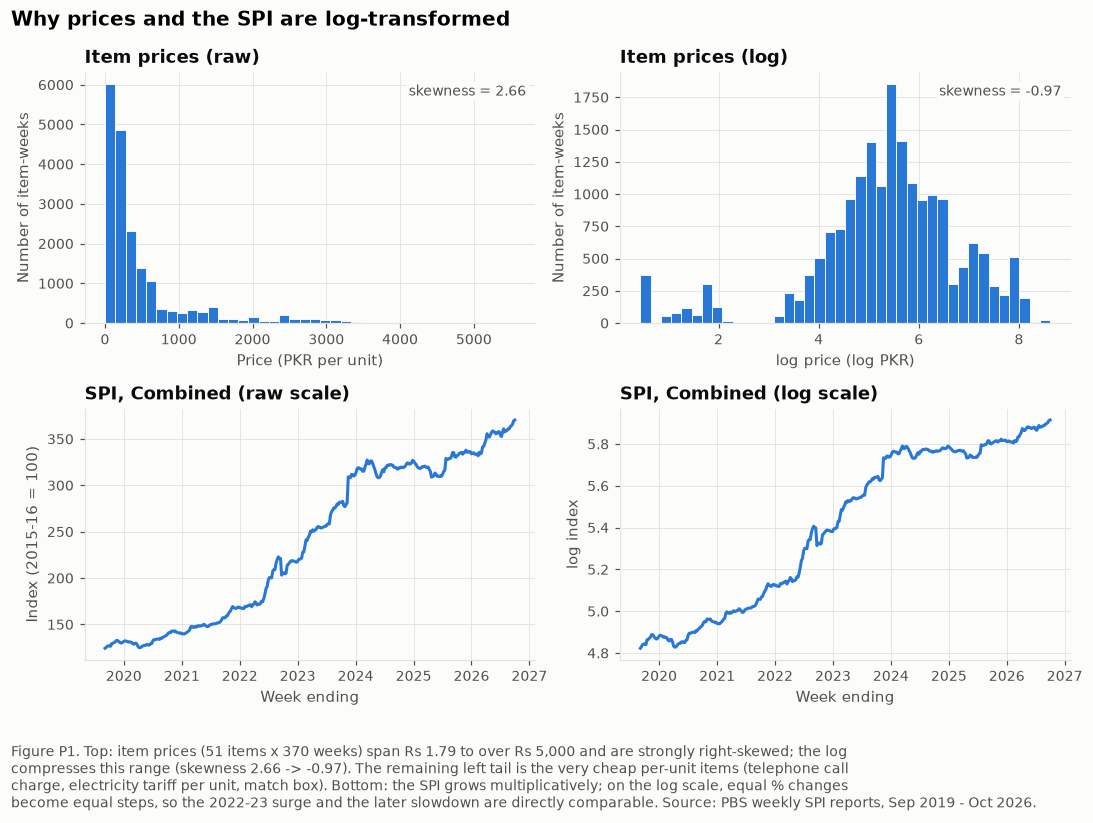

In [16]:
comb = df[df["group"] == "Combined"].sort_values("week_end")
fig, axes = plt.subplots(2, 2, figsize=(10, 6.6))

# Top row: item prices are a distribution question, so histograms.
for ax, x, title, xlabel in [
    (axes[0, 0], items["price"], "Item prices (raw)", "Price (PKR per unit)"),
    (axes[0, 1], items["log_price"], "Item prices (log)", "log price (log PKR)"),
]:
    ax.hist(x.dropna(), bins=40, color=SERIES[0], edgecolor="#fcfcfb", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of item-weeks")
    ax.text(0.98, 0.95, f"skewness = {x.skew():.2f}", transform=ax.transAxes, ha="right", va="top",
            color=INK_SECONDARY, fontsize=9,
            bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1.5))

# Bottom row: the SPI is a growth question, so time plots. Constant % growth is a curve on the
# raw scale and a straight line on the log scale.
axes[1, 0].plot(comb["week_end"], comb["spi"], color=SERIES[0])
axes[1, 0].set_title("SPI, Combined (raw scale)")
axes[1, 0].set_ylabel("Index (2015-16 = 100)")
axes[1, 1].plot(comb["week_end"], comb["log_spi"], color=SERIES[0])
axes[1, 1].set_title("SPI, Combined (log scale)")
axes[1, 1].set_ylabel("log index")
for ax in axes[1]:
    ax.set_xlabel("Week ending")

fig.suptitle("Why prices and the SPI are log-transformed", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.text(0.01, -0.03,
         "Figure P1. Top: item prices (51 items x 370 weeks) span Rs 1.79 to over Rs 5,000 and are strongly right-skewed; "
         "the log\ncompresses this range (skewness 2.66 -> -0.97). The remaining left tail is the very cheap per-unit "
         "items (telephone call\ncharge, electricity tariff per unit, match box). Bottom: the SPI grows multiplicatively; "
         "on the log scale, equal % changes\nbecome equal steps, so the 2022-23 surge and the later slowdown are "
         "directly comparable. Source: PBS weekly SPI reports, Sep 2019 - Oct 2026.",
         ha="left", va="top", fontsize=9, color=INK_SECONDARY)
fig.tight_layout()
fig.savefig(FIG_DIR / "figP1_log_transform.png")
plt.show()

### Scaling: Min-Max normalisation and Z-score standardisation

Predictors live on very different scales: the policy rate runs 7–22%, weekly changes run about ±3%, and log FX runs
about 5.0–5.7. Distance-based models such as KNN, and regularised regressions, need comparable scales.

* **Min-Max:** $x' = \dfrac{x - \min}{\max - \min}$ maps the training range to [0, 1].
* **Z-score:** $z = \dfrac{x - \bar{x}}{s}$ gives mean 0 and standard deviation 1.

**Leakage rule:** the min, max, mean and SD are computed on the **training period only** (up to 31 Dec 2024), then
applied unchanged to later weeks. Otherwise the model would "see" future price levels. Held-out weeks can therefore
fall outside [0, 1]; that is expected.

In [17]:
to_scale = ["log_spi", "log_fx", "policy_rate", "spi_wow_pct_lag1", "spi_wow_pct_lag2", "spi_wow_pct_lag4",
            "fx_wow_pct", "fx_wow_pct_lag1", "ramadan_days_in_week", "weeks_to_ramadan"]
train = df["week_end"] <= TRAIN_END

params = pd.DataFrame({
    "train_min": df.loc[train, to_scale].min(),
    "train_max": df.loc[train, to_scale].max(),
    "train_mean": df.loc[train, to_scale].mean(),
    "train_sd": df.loc[train, to_scale].std(),
})
for c in to_scale:
    p = params.loc[c]
    df[f"{c}_mm"] = (df[c] - p["train_min"]) / (p["train_max"] - p["train_min"])
    df[f"{c}_z"] = (df[c] - p["train_mean"]) / p["train_sd"]
params.to_csv(TABLE_DIR / "scaling_parameters.csv")   # reused by the modeling notebooks

# Verify: on the training rows, Min-Max spans [0, 1] and Z-scores have mean 0 and SD 1.
check = pd.DataFrame({
    "mm_min (train)": df.loc[train, [f"{c}_mm" for c in to_scale]].min().values,
    "mm_max (train)": df.loc[train, [f"{c}_mm" for c in to_scale]].max().values,
    "z_mean (train)": df.loc[train, [f"{c}_z" for c in to_scale]].mean().values,
    "z_sd (train)": df.loc[train, [f"{c}_z" for c in to_scale]].std().values,
    "mm_max (held-out)": df.loc[~train, [f"{c}_mm" for c in to_scale]].max().values,
}, index=to_scale)
print(f"training rows: {train.sum():,} | held-out rows: {(~train).sum():,}")
display(check.round(3))

training rows: 1,668 | held-out rows: 552


,mm_min (train),mm_max (train),z_mean (train),z_sd (train),mm_max (held-out)
log_spi,0.0,1.0,0.0,1.0,1.107
log_fx,0.0,1.0,-0.0,1.0,0.895
policy_rate,0.0,1.0,-0.0,1.0,0.400
spi_wow_pct_lag1,0.0,1.0,-0.0,1.0,0.695
spi_wow_pct_lag2,0.0,1.0,0.0,1.0,0.695
spi_wow_pct_lag4,0.0,1.0,0.0,1.0,0.695
fx_wow_pct,0.0,1.0,-0.0,1.0,0.314
fx_wow_pct_lag1,0.0,1.0,-0.0,1.0,0.314
ramadan_days_in_week,0.0,1.0,-0.0,1.0,1.000
weeks_to_ramadan,0.0,1.0,0.0,1.0,1.004


### Categorical encoding

Nominal categories become **Boolean dummy (0/1) indicators** (Unit 04). In a regression one dummy per variable is left
out as the **reference category**, to avoid perfect collinearity (the "dummy variable trap"); its effect is absorbed
by the intercept.

* **Consumption group** → `grp_Q1 … grp_Q5, grp_Combined` (reference for regression: `grp_Combined`).
* **Monetary-policy action in the week** → `mpc_hike`, `mpc_cut`, `mpc_hold` (reference: no MPC meeting that week).
* Yes/no flags (fuel-revision week, filled week, …) are stored as 0/1 integers.

In [18]:
# Assign each SBP decision to the SPI week (Friday-Thursday) that contains it.
mpc_week = mpc.assign(week_end=mpc["decision_date"]
                      + pd.to_timedelta((3 - mpc["decision_date"].dt.weekday) % 7, unit="D"))
assert not mpc_week["week_end"].duplicated().any(), "two decisions in one week"
df = df.merge(mpc_week[["week_end", "action"]].rename(columns={"action": "mpc_action"}),
              on="week_end", how="left", validate="many_to_one")
df["mpc_action"] = df["mpc_action"].fillna("none")
df = pd.concat([df, pd.get_dummies(df["mpc_action"], prefix="mpc", dtype=int).drop(columns="mpc_none")], axis=1)

# Boolean columns -> 0/1 integers (missing stays missing).
bool_cols = ["filled_from_next_report", "revised_by_next_report", "spi_year_ago_from_lag52",
             "mpc_decision_in_week"] + [c for c in df.columns if c.startswith("grp_")]
df[bool_cols] = df[bool_cols].astype(int)
df["fuel_revision_week"] = df["fuel_revision_week"].astype("Int64")

print(pd.crosstab(df.loc[df["group"] == "Combined", "mpc_action"], "weeks"))
display(df[["week_end", "group", "mpc_action", "mpc_hike", "mpc_cut", "mpc_hold"] +
           [f"grp_{g}" for g in GROUPS]].query("mpc_action != 'none'").head(6))

col_0       weeks
mpc_action       
cut            13
hike           12
hold           31
none          314


,week_end,group,mpc_action,mpc_hike,mpc_cut,mpc_hold,grp_Q1,grp_Q2,grp_Q3,grp_Q4,grp_Q5,grp_Combined
2,2019-09-19,Combined,hold,0,0,1,0,0,0,0,0,1
12,2019-11-28,Combined,hold,0,0,1,0,0,0,0,0,1
21,2020-01-30,Combined,hold,0,0,1,0,0,0,0,0,1
28,2020-03-19,Combined,cut,0,1,0,0,0,0,0,0,1
29,2020-03-26,Combined,cut,0,1,0,0,0,0,0,0,1
32,2020-04-16,Combined,cut,0,1,0,0,0,0,0,0,1


## 3. Save the modeling-ready datasets

* `data/processed/master_model_ready.csv`: the week × group dataset with every preparation step above.
* `data/processed/items_weekly_panel.csv`: the completed week × item panel (prices, log prices, impacts, categories).
* `data/processed/DATA_DICTIONARY.md`: every column, with type, % missing and meaning.

In [19]:
df = df.sort_values(["week_end", "group"]).reset_index(drop=True)
df.to_csv(DATA / "processed" / "master_model_ready.csv", index=False, date_format="%Y-%m-%d")
items_out = items[["week_end", "item_id", "item_name", "category", "unit", "price", "log_price", "price_wow_pct",
                   "price_prev_week", "price_year_ago", "pct_wow", "pct_yoy", "weight_q1", "weight_combined",
                   "impact_q1", "impact_combined", "price_filled_from_next_report", "source_file"]]
items_out.to_csv(DATA / "processed" / "items_weekly_panel.csv", index=False, date_format="%Y-%m-%d")
print(f"master_model_ready.csv : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"items_weekly_panel.csv : {items_out.shape[0]:,} rows x {items_out.shape[1]} columns")

master_model_ready.csv : 2,220 rows x 70 columns
items_weekly_panel.csv : 18,870 rows x 18 columns


In [20]:
# Data dictionary: descriptions for every column of the modeling-ready dataset.
desc = {
    "week_end": "Thursday ending the SPI week (reports dated otherwise are aligned to the nearest Thursday)",
    "group": "Consumption group: Q1 (poorest) ... Q5 (richest), or Combined (national)",
    "spi": "Sensitive Price Indicator, index (2015-16 = 100); revised value where PBS later revised it",
    "spi_prev_week": "Previous week's SPI as printed in this week's report (documentation column)",
    "spi_year_ago": "SPI in the corresponding week a year earlier (reported; else own value 52 weeks earlier)",
    "pct_wow_reported": "Week-on-week % change as printed by PBS (documentation column)",
    "pct_yoy_reported": "Year-on-year % change as printed by PBS (documentation column)",
    "source_file": "Raw report the row was parsed from",
    "week_end_reported": "Week-ending date printed in the report, before Thursday alignment",
    "filled_from_next_report": "1 if no report was published that week and SPI was taken from the next report",
    "revised_by_next_report": "1 if PBS revised this week's SPI in the following report (revised value used)",
    "fx_pkr_usd_wavg": "Average PKR per USD over the SPI week (Fri-Thu), Yahoo Finance PKR=X",
    "ramadan_days_in_week": "Number of Ramadan days in the SPI week (0-7)",
    "eid_fitr_days_in_week": "Number of Eid ul-Fitr holiday days in the SPI week (0-3)",
    "eid_adha_days_in_week": "Number of Eid ul-Adha holiday days in the SPI week (0-3)",
    "weeks_to_ramadan": "Weeks until the next Ramadan starts",
    "policy_rate": "SBP policy rate in force at the end of the week (%)",
    "mpc_decision_in_week": "1 if an SBP Monetary Policy Committee decision fell in the week",
    "log_spi": "Natural log of spi",
    "spi_wow_pct": "Week-on-week % change in spi (computed from the cleaned series)",
    "spi_yoy_pct": "Year-on-year % change in spi",
    "fx_wow_pct": "Week-on-week % change in fx_pkr_usd_wavg",
    "spi_wow_pct_lag1": "spi_wow_pct one week earlier",
    "spi_wow_pct_lag2": "spi_wow_pct two weeks earlier",
    "spi_wow_pct_lag4": "spi_wow_pct four weeks earlier",
    "fx_wow_pct_lag1": "fx_wow_pct one week earlier",
    "target_spi_wow_pct_next": "TARGET: next week's spi_wow_pct for the same group",
    "spi_year_ago_from_lag52": "1 if spi_year_ago was filled from the group's own value 52 weeks earlier",
    "petrol_pct_wow": "Week-on-week % change in the average petrol (Super) price",
    "diesel_pct_wow": "Week-on-week % change in the average Hi-Speed Diesel price",
    "fuel_revision_week": "1 if petrol or diesel moved by more than 1% (administered price revision)",
    "log_fx": "Natural log of fx_pkr_usd_wavg",
    "mpc_action": "SBP decision in the week: hike, cut, hold, or none",
    "mpc_hike": "1 if the SBP raised the policy rate in the week",
    "mpc_cut": "1 if the SBP cut the policy rate in the week",
    "mpc_hold": "1 if the SBP met and held the policy rate in the week",
}
for g in GROUPS:
    desc[f"grp_{g}"] = f"1 if the row belongs to group {g} (dummy)"
for cat in ["food", "energy", "clothing_footwear", "household"]:
    desc[f"contrib_{cat}_q1"] = f"Percentage points of the lowest quintile's weekly SPI change due to {cat} items"
    desc[f"contrib_{cat}_comb"] = f"Percentage points of the Combined weekly SPI change due to {cat} items"
for c in to_scale:
    desc[f"{c}_mm"] = f"{c}, Min-Max scaled with training-period (to {TRAIN_END:%Y-%m-%d}) min/max"
    desc[f"{c}_z"] = f"{c}, Z-score standardised with training-period mean/SD"

missing_cols = [c for c in df.columns if c not in desc]
assert not missing_cols, f"undocumented columns: {missing_cols}"

lines = ["# Data dictionary: master_model_ready.csv", "",
         "1 row = 1 SPI week (ending Thursday) x 1 consumption group. "
         f"{df.shape[0]:,} rows x {df.shape[1]} columns, {df['week_end'].min():%d %b %Y} to "
         f"{df['week_end'].max():%d %b %Y}. Generated by `notebooks/01_data_preparation.ipynb`.", "",
         "| Column | Type | % missing | Description |", "|---|---|---|---|"]
for c in df.columns:
    lines.append(f"| `{c}` | {df[c].dtype} | {100 * df[c].isna().mean():.1f} | {desc[c]} |")
(DATA / "processed" / "DATA_DICTIONARY.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"documented {len(df.columns)} columns -> data/processed/DATA_DICTIONARY.md")

documented 70 columns -> data/processed/DATA_DICTIONARY.md


## 4. Summary of preparation decisions

| # | Decision | Rationale | Effect |
|---|---|---|---|
| D1 | Align report dates to the nearest Thursday | a few holiday releases fell on Wed/Sat; a regular weekly grid is needed for lags | 14 reports realigned |
| D2 | Fill weeks without a report from the next report's "previous week" values | official PBS figures, not imputation | 11 weeks recovered, 0 missing SPI |
| D3 | Use PBS's revised values when a later report revises a week | latest vintage is the best estimate | 13 values revised |
| D4 | Drop two FX bad ticks before weekly averaging | one-day spikes that fully reverse | 2 days dropped |
| D5 | Fuel-revision week = petrol or diesel moved > 1% | administered prices change in discrete steps | see §2.3 |
| P1 | Complete item panel on a week × item grid, with the D2 rule | explicit missing weeks; prices for every week | §2.2 |
| P2 | Set Combined impacts of 5 Sep 2019 to missing | PBS printed the Q1 column twice | 1 week |
| P3 | Year-ago SPI from the 52-week lag where not reported | matches the reported value closely (§2.3) | gaps filled |
| P4 | No mean/median imputation; structural NaNs dropped listwise at modeling time | imputing a time series invents jumps | see §2.3 |
| P5 | Log of SPI, FX and item prices | multiplicative growth / heavy right skew | Figure P1 |
| P6 | Min-Max and Z-score with training-period statistics only | prevents look-ahead leakage | `reports/tables/scaling_parameters.csv` |
| P7 | Dummy-encode group and MPC action | nominal categories for ML models | reference categories noted |